In [1]:
from IPython.utils import io

with io.capture_output():
    %run ../01_eda_exploratory_data_analysis/01_data_overview.ipynb
    %run ../01_eda_exploratory_data_analysis/02_statistical_analysis.ipynb
    %run ../01_eda_exploratory_data_analysis/03_correlation_analysis.ipynb

print("✅ Connected to notebooks")

✅ Connected to notebooks


###  Price Line Chart

📈 PRICE LINE CHART


NameError: name 'DateFormatter' is not defined

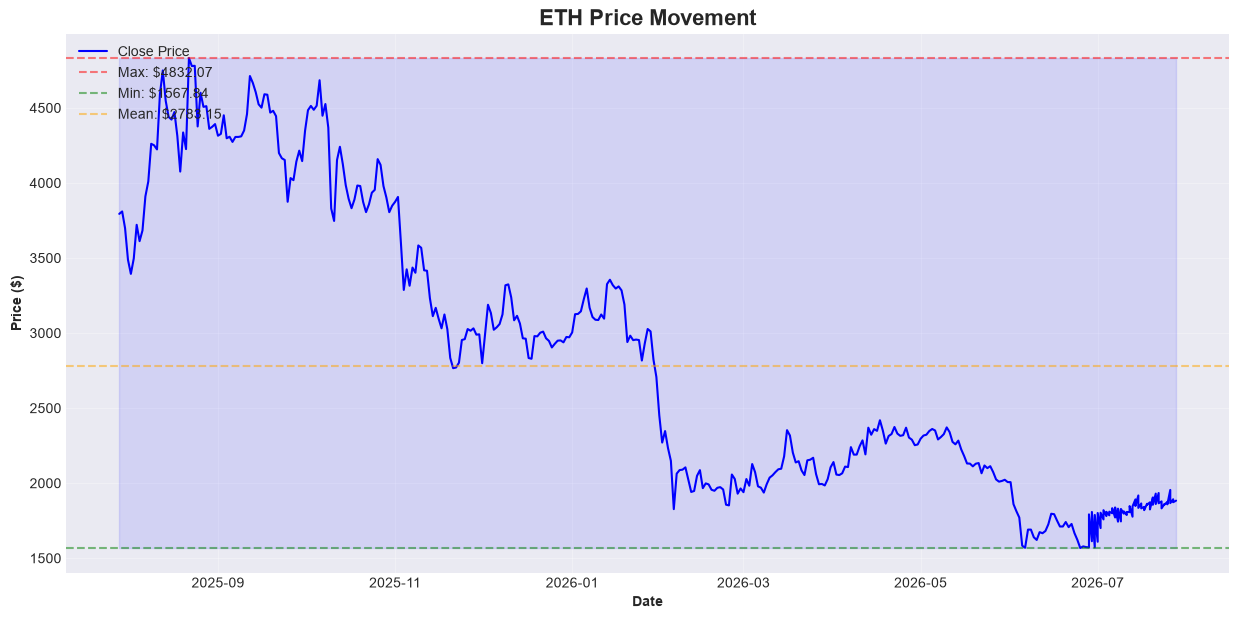

In [2]:
# ====================================================================
# 📈 PRICE LINE CHART
# ====================================================================

print("=" * 60)
print("📈 PRICE LINE CHART")
print("=" * 60)

fig, ax = plt.subplots(figsize=(15, 7))

# Plot price line
ax.plot(df.index, df[price_col], linewidth=1.5, color='blue', label='Close Price')

# Add horizontal lines for min and max
ax.axhline(y=df[price_col].max(), color='red', linestyle='--', alpha=0.5, 
           label=f'Max: ${df[price_col].max():.2f}')
ax.axhline(y=df[price_col].min(), color='green', linestyle='--', alpha=0.5, 
           label=f'Min: ${df[price_col].min():.2f}')
ax.axhline(y=df[price_col].mean(), color='orange', linestyle='--', alpha=0.5, 
           label=f'Mean: ${df[price_col].mean():.2f}')

# Fill between min and max
ax.fill_between(df.index, df[price_col].min(), df[price_col].max(), 
                alpha=0.1, color='blue')

# Formatting
ax.set_title('ETH Price Movement', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Price ($)', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Format x-axis dates
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(plt.MaxNLocator(15))

plt.tight_layout()
plt.show()

print("\n✅ Price line chart displayed")

###  Price with Moving Averages

📊 PRICE WITH MOVING AVERAGES


NameError: name 'DateFormatter' is not defined

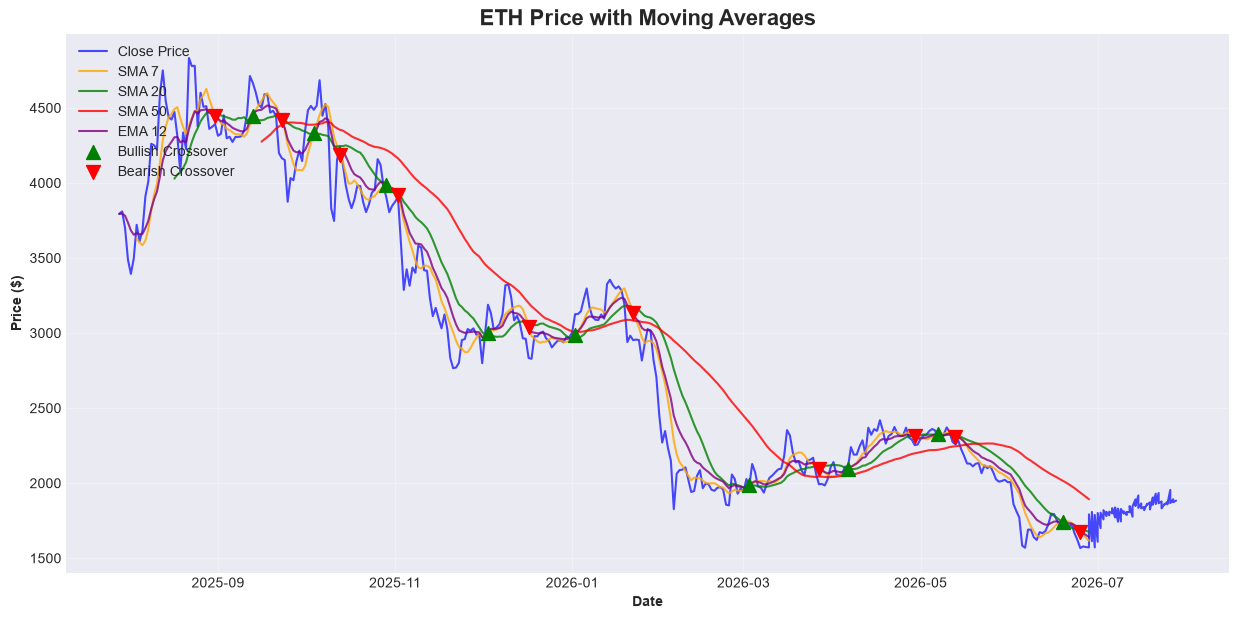

In [3]:
# ====================================================================
# 📊 PRICE WITH MOVING AVERAGES
# ====================================================================

print("=" * 60)
print("📊 PRICE WITH MOVING AVERAGES")
print("=" * 60)

fig, ax = plt.subplots(figsize=(15, 7))

# Plot price
ax.plot(df.index, df[price_col], linewidth=1.5, color='blue', label='Close Price', alpha=0.7)

# Add moving averages
if 'SMA_7' in df.columns:
    ax.plot(df.index, df['SMA_7'], linewidth=1.5, color='orange', label='SMA 7', alpha=0.8)
if 'SMA_20' in df.columns:
    ax.plot(df.index, df['SMA_20'], linewidth=1.5, color='green', label='SMA 20', alpha=0.8)
if 'SMA_50' in df.columns:
    ax.plot(df.index, df['SMA_50'], linewidth=1.5, color='red', label='SMA 50', alpha=0.8)
if 'EMA_12' in df.columns:
    ax.plot(df.index, df['EMA_12'], linewidth=1.5, color='purple', label='EMA 12', alpha=0.8)

# Add crossover points (if SMA_7 and SMA_20 exist)
if 'SMA_7' in df.columns and 'SMA_20' in df.columns:
    # Find crossovers
    crossover = (df['SMA_7'] > df['SMA_20']) & (df['SMA_7'].shift(1) <= df['SMA_20'].shift(1))
    crossunder = (df['SMA_7'] < df['SMA_20']) & (df['SMA_7'].shift(1) >= df['SMA_20'].shift(1))
    
    # Mark crossovers
    ax.scatter(df.index[crossover], df['SMA_7'][crossover], 
              color='green', s=100, marker='^', label='Bullish Crossover', zorder=5)
    ax.scatter(df.index[crossunder], df['SMA_7'][crossunder], 
              color='red', s=100, marker='v', label='Bearish Crossover', zorder=5)

# Formatting
ax.set_title('ETH Price with Moving Averages', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Price ($)', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Format x-axis dates
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(plt.MaxNLocator(15))

plt.tight_layout()
plt.show()

print("\n✅ Price with moving averages displayed")

###  Candlestick-like Chart (Simplified)

📊 CANDLESTICK-LIKE CHART


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

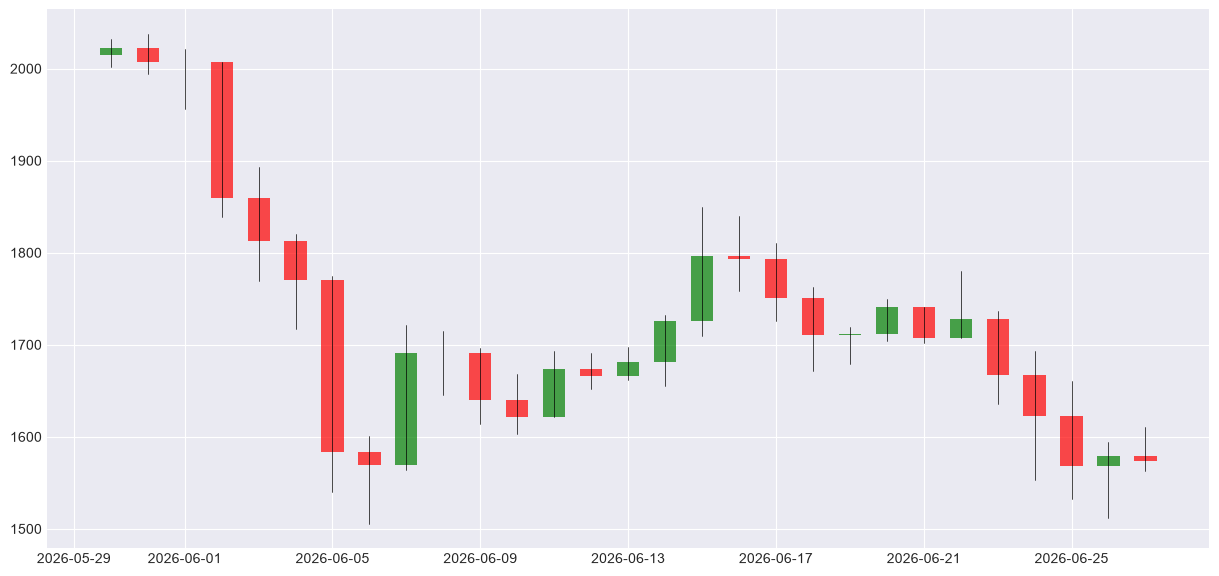

In [4]:
# ====================================================================
# 📊 CANDLESTICK-LIKE CHART (Simplified)
# ====================================================================

print("=" * 60)
print("📊 CANDLESTICK-LIKE CHART")
print("=" * 60)

# Use only last 90 days for better visibility
if len(df) > 90:
    plot_df = df.iloc[-90:]
else:
    plot_df = df

fig, ax = plt.subplots(figsize=(15, 7))

# Plot candles as vertical lines with markers
for i, idx in enumerate(plot_df.index):
    # Body color
    if plot_df.loc[idx, 'close'] >= plot_df.loc[idx, 'open']:
        color = 'green'
    else:
        color = 'red'
    
    # Plot the high-low line (wick)
    ax.plot([idx, idx], [plot_df.loc[idx, 'low'], plot_df.loc[idx, 'high']], 
            color='black', linewidth=0.5)
    
    # Plot the open-close body
    body_bottom = min(plot_df.loc[idx, 'open'], plot_df.loc[idx, 'close'])
    body_top = max(plot_df.loc[idx, 'open'], plot_df.loc[idx, 'close'])
    ax.bar(idx, body_top - body_bottom, bottom=body_bottom, 
           color=color, width=0.6, alpha=0.7)

# Add price line overlay
ax.plot(plot_df.index, plot_df[price_col], linewidth=1.5, color='blue', alpha=0.5, label='Close Price')

# Formatting
ax.set_title('ETH Candlestick Pattern (Last 90 Days)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Price ($)', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Format x-axis dates
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(plt.MaxNLocator(20))

plt.tight_layout()
plt.show()

print("\n✅ Candlestick chart displayed")

### Price Patterns - Support & Resistance

📊 SUPPORT & RESISTANCE LEVELS


NameError: name 'DateFormatter' is not defined

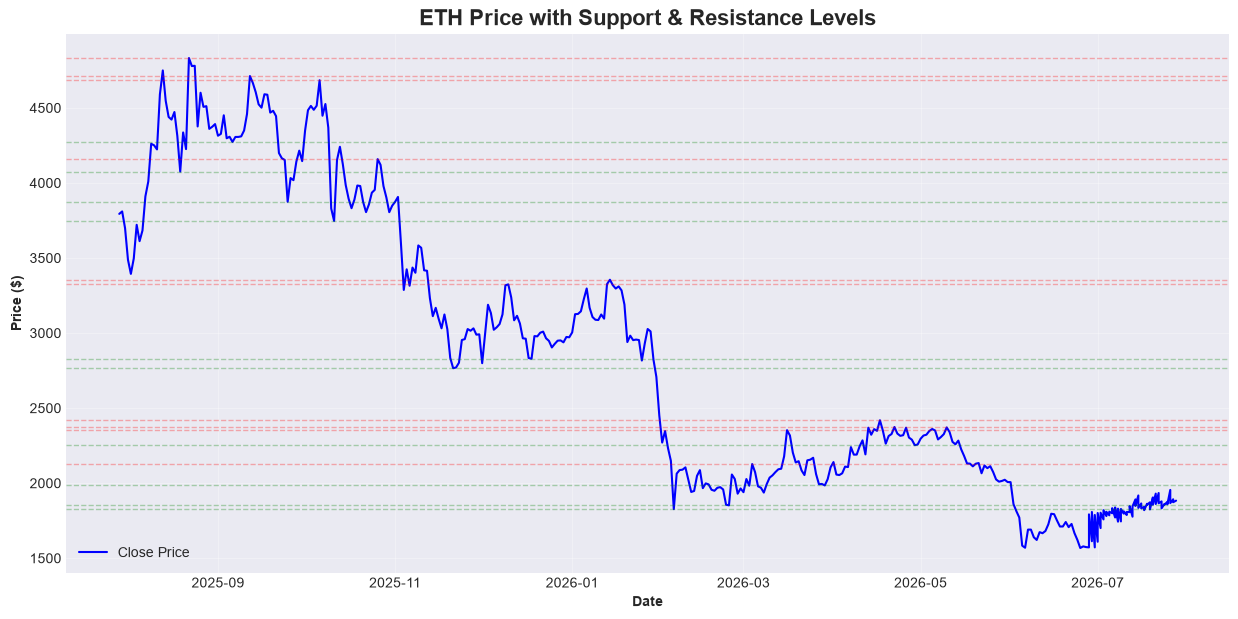

In [5]:
# ====================================================================
# 📊 SUPPORT & RESISTANCE LEVELS
# ====================================================================

print("=" * 60)
print("📊 SUPPORT & RESISTANCE LEVELS")
print("=" * 60)

fig, ax = plt.subplots(figsize=(15, 7))

# Plot price
ax.plot(df.index, df[price_col], linewidth=1.5, color='blue', label='Close Price')

# Calculate support and resistance levels (simple method)
# Resistance: local maxima
window = 20
rolling_max = df[price_col].rolling(window=window, center=True).max()
rolling_min = df[price_col].rolling(window=window, center=True).min()

# Find support and resistance
resistance_points = []
support_points = []

for i in range(window, len(df) - window):
    if df[price_col].iloc[i] == rolling_max.iloc[i]:
        resistance_points.append(i)
    if df[price_col].iloc[i] == rolling_min.iloc[i]:
        support_points.append(i)

# Plot support and resistance lines
if resistance_points:
    for point in resistance_points[:10]:  # Limit to 10 points
        ax.axhline(y=df[price_col].iloc[point], color='red', linestyle='--', alpha=0.3, linewidth=1)
        
# Plot support lines
if support_points:
    for point in support_points[:10]:  # Limit to 10 points
        ax.axhline(y=df[price_col].iloc[point], color='green', linestyle='--', alpha=0.3, linewidth=1)

# Formatting
ax.set_title('ETH Price with Support & Resistance Levels', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Price ($)', fontweight='bold')
ax.legend(['Close Price'])
ax.grid(True, alpha=0.3)

# Format x-axis dates
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(plt.MaxNLocator(15))

plt.tight_layout()
plt.show()

print("\n✅ Support & resistance chart displayed")

###  Price Patterns - Trend Lines

📊 TREND LINES


NameError: name 'DateFormatter' is not defined

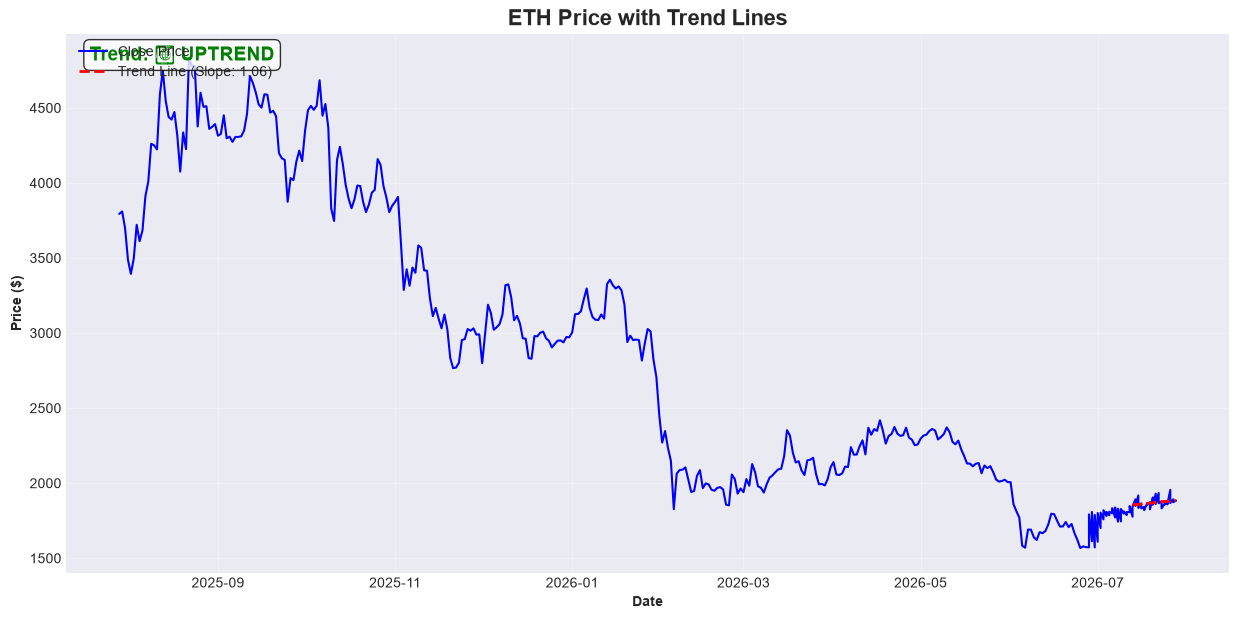

In [6]:
# ====================================================================
# 📊 TREND LINES
# ====================================================================

print("=" * 60)
print("📊 TREND LINES")
print("=" * 60)

fig, ax = plt.subplots(figsize=(15, 7))

# Plot price
ax.plot(df.index, df[price_col], linewidth=1.5, color='blue', label='Close Price')

# Simple trend detection (last 30 days)
if len(df) > 30:
    recent_df = df.iloc[-30:]
    
    # Simple linear regression for trend
    x = np.arange(len(recent_df))
    y = recent_df[price_col].values
    
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    
    # Plot trend line
    ax.plot(recent_df.index, p(x), color='red', linewidth=2, 
           label=f'Trend Line (Slope: {z[0]:.2f})', linestyle='--')
    
    # Determine trend direction
    if z[0] > 0:
        trend_direction = "📈 UPTREND"
        trend_color = 'green'
    elif z[0] < 0:
        trend_direction = "📉 DOWNTREND"
        trend_color = 'red'
    else:
        trend_direction = "➡️ SIDEWAYS"
        trend_color = 'orange'
    
    # Add trend annotation
    ax.text(0.02, 0.95, f"Trend: {trend_direction}", 
            transform=ax.transAxes, fontsize=14, fontweight='bold',
            color=trend_color,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Formatting
ax.set_title('ETH Price with Trend Lines', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Price ($)', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Format x-axis dates
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(plt.MaxNLocator(15))

plt.tight_layout()
plt.show()

print("\n✅ Trend lines displayed")

### Price Patterns - Seasonal Patterns

📊 SEASONAL PATTERNS


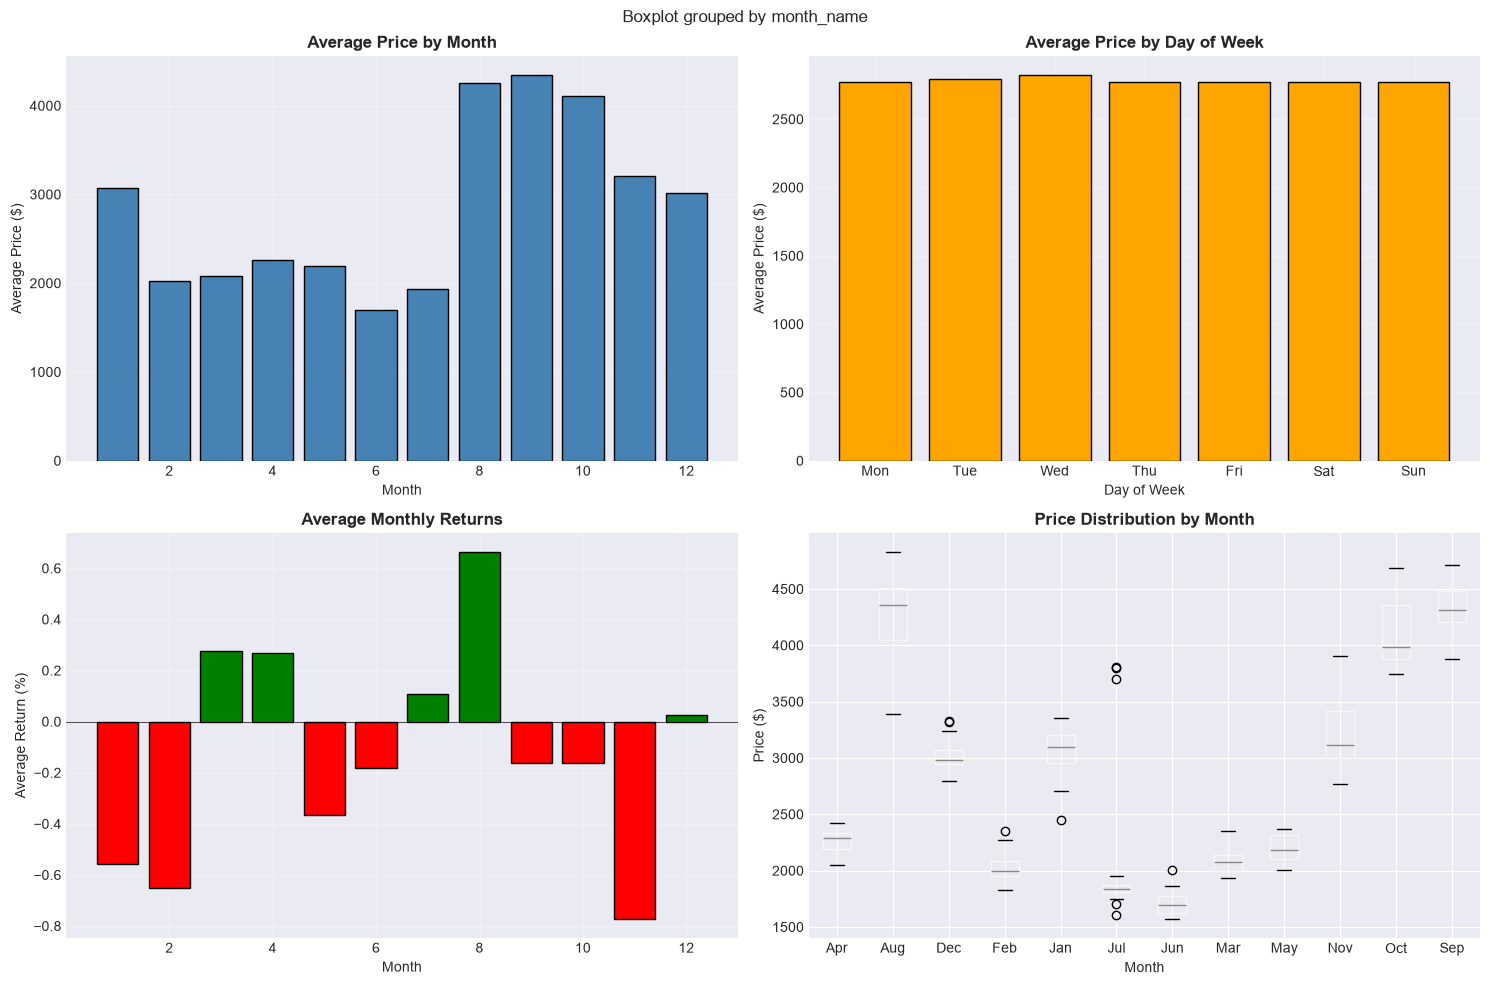


✅ Seasonal patterns displayed


In [7]:
# ====================================================================
# 📊 SEASONAL PATTERNS
# ====================================================================

print("=" * 60)
print("📊 SEASONAL PATTERNS")
print("=" * 60)

# Create month and day columns
df_monthly = df.copy()
df_monthly['month'] = df_monthly.index.month
df_monthly['day_of_week'] = df_monthly.index.dayofweek
df_monthly['week'] = df_monthly.index.isocalendar().week

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Monthly Average Price
monthly_avg = df_monthly.groupby('month')[price_col].mean()
axes[0, 0].bar(monthly_avg.index, monthly_avg.values, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Average Price by Month', fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Average Price ($)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Daily Average Price (Day of Week)
daily_avg = df_monthly.groupby('day_of_week')[price_col].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0, 1].bar(days, daily_avg.values, color='orange', edgecolor='black')
axes[0, 1].set_title('Average Price by Day of Week', fontweight='bold')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Average Price ($)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Monthly Returns
monthly_returns = df_monthly.groupby('month')['returns'].mean() if 'returns' in df_monthly.columns else None
if monthly_returns is not None:
    colors = ['green' if x > 0 else 'red' for x in monthly_returns.values]
    axes[1, 0].bar(monthly_returns.index, monthly_returns.values, color=colors, edgecolor='black')
    axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1, 0].set_title('Average Monthly Returns', fontweight='bold')
    axes[1, 0].set_xlabel('Month')
    axes[1, 0].set_ylabel('Average Return (%)')
    axes[1, 0].grid(True, alpha=0.3)

# 4. Boxplot by Month
if len(df) > 0:
    df_monthly['month_name'] = df_monthly.index.strftime('%b')
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    available_months = [m for m in month_order if m in df_monthly['month_name'].values]
    
    if available_months:
        df_monthly.boxplot(column=price_col, by='month_name', ax=axes[1, 1])
        axes[1, 1].set_title('Price Distribution by Month', fontweight='bold')
        axes[1, 1].set_xlabel('Month')
        axes[1, 1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

print("\n✅ Seasonal patterns displayed")

### Price Patterns - Volatility Patterns

📊 VOLATILITY PATTERNS


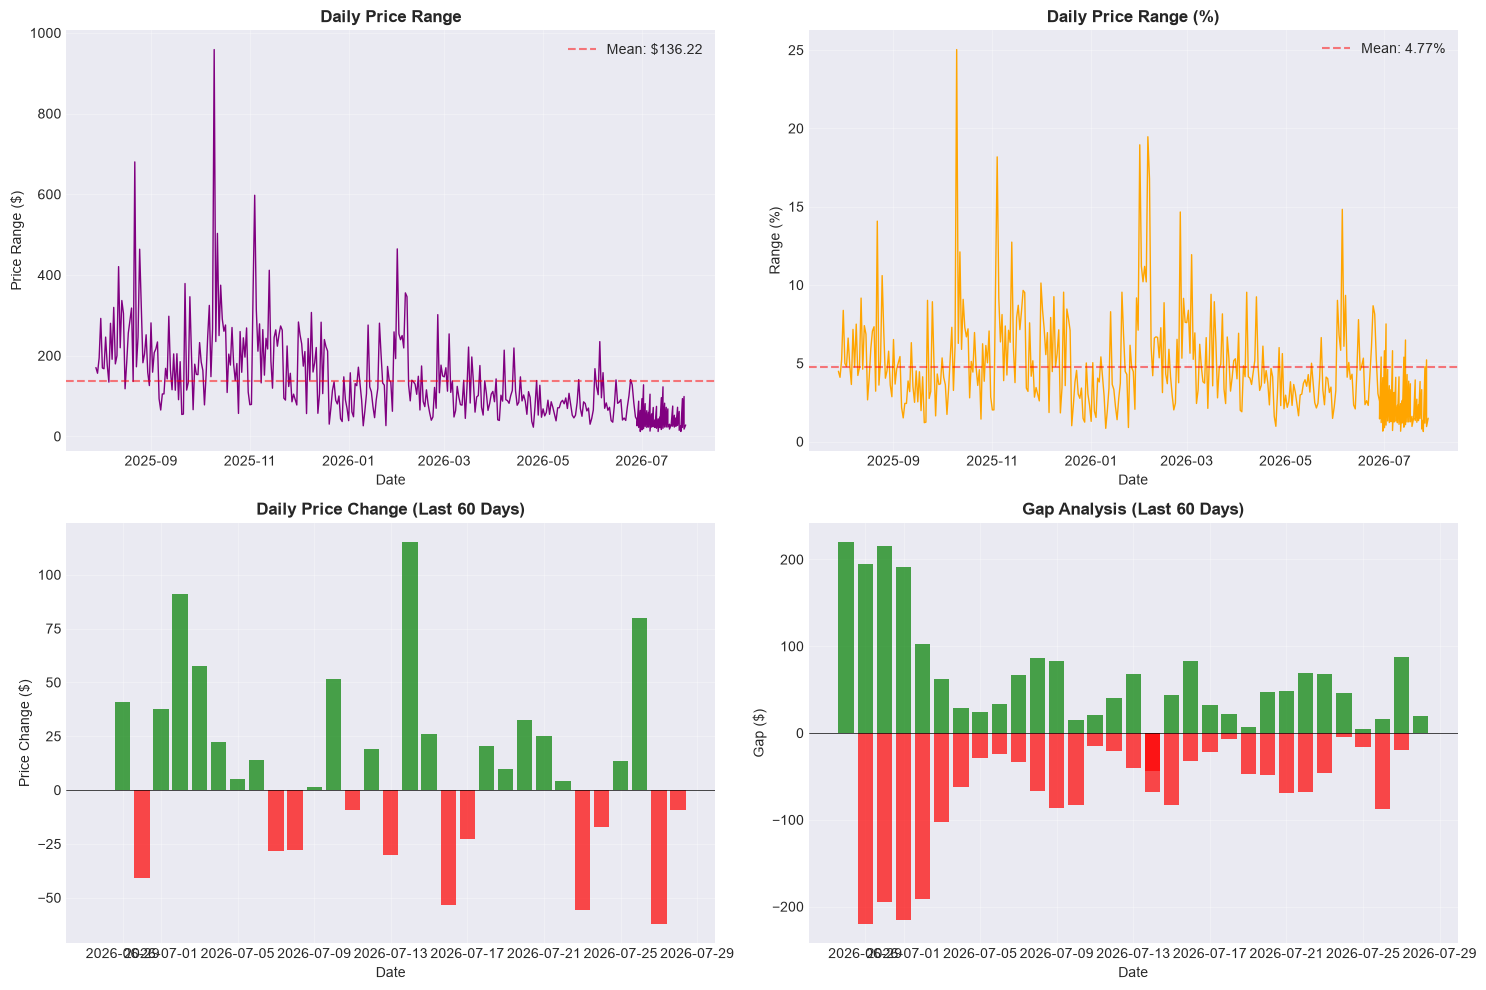


✅ Volatility patterns displayed


In [8]:
# ====================================================================
# 📊 VOLATILITY PATTERNS
# ====================================================================

print("=" * 60)
print("📊 VOLATILITY PATTERNS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Daily Price Range
df['range'] = df['high'] - df['low']
axes[0, 0].plot(df.index, df['range'], linewidth=1, color='purple')
axes[0, 0].set_title('Daily Price Range', fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price Range ($)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=df['range'].mean(), color='red', linestyle='--', 
                   alpha=0.5, label=f'Mean: ${df["range"].mean():.2f}')
axes[0, 0].legend()

# 2. Price Range % (High-Low as % of Close)
df['range_pct'] = (df['high'] - df['low']) / df['close'] * 100
axes[0, 1].plot(df.index, df['range_pct'], linewidth=1, color='orange')
axes[0, 1].set_title('Daily Price Range (%)', fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Range (%)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=df['range_pct'].mean(), color='red', linestyle='--', 
                   alpha=0.5, label=f'Mean: {df["range_pct"].mean():.2f}%')
axes[0, 1].legend()

# 3. Price Change (Close - Open)
df['change'] = df['close'] - df['open']
colors = ['green' if x > 0 else 'red' for x in df['change'].iloc[-60:]]
axes[1, 0].bar(df.index[-60:], df['change'].iloc[-60:], color=colors, alpha=0.7)
axes[1, 0].axhline(y=0, color='black', linewidth=0.5)
axes[1, 0].set_title('Daily Price Change (Last 60 Days)', fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Price Change ($)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Gap analysis (Close vs Open)
df['gap'] = df['open'] - df['close'].shift(1)
colors = ['green' if x > 0 else 'red' for x in df['gap'].iloc[-60:]]
axes[1, 1].bar(df.index[-60:], df['gap'].iloc[-60:], color=colors, alpha=0.7)
axes[1, 1].axhline(y=0, color='black', linewidth=0.5)
axes[1, 1].set_title('Gap Analysis (Last 60 Days)', fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Gap ($)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Volatility patterns displayed")